In [1]:
import h5py
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def get_dataset_name(file_name_with_dir):
    filename_without_dir = file_name_with_dir.split('/')[-1]
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = '_'.join(temp)
    return dataset_name

In [3]:
filename_path = 'data/Intra/train/rest_105923_1.h5'

with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    print(dataset_name)
    matrix = f.get(dataset_name)[()]
    print(type(matrix))
    print(matrix.shape)

rest_105923
<class 'numpy.ndarray'>
(248, 35624)


In [ ]:
data = pd.DataFrame(matrix)

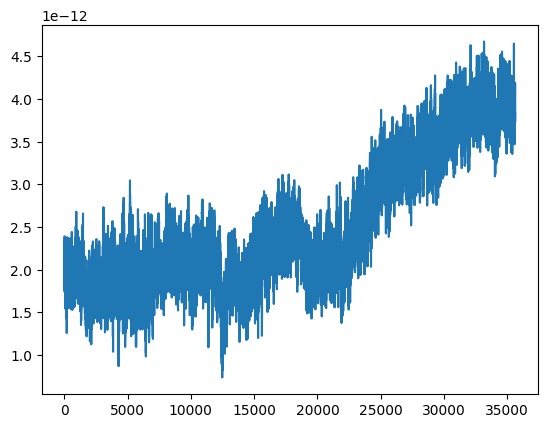

In [57]:
plt.plot(data.iloc[0])

3563

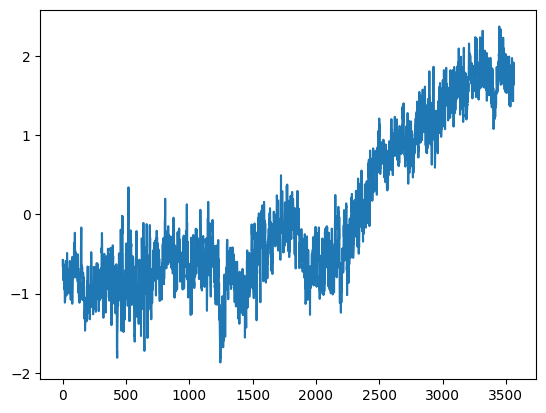

In [18]:
means = pd.Series(data.iloc[0].to_numpy()).groupby(lambda i: i // 10).mean()
plt.plot(means)
means.size

883624

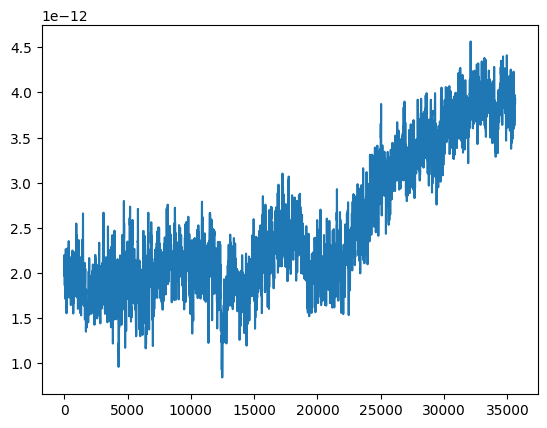

In [43]:
dropped_out = data.iloc[:, ::10]
plt.plot(dropped_out.iloc[0])
dropped_out.size

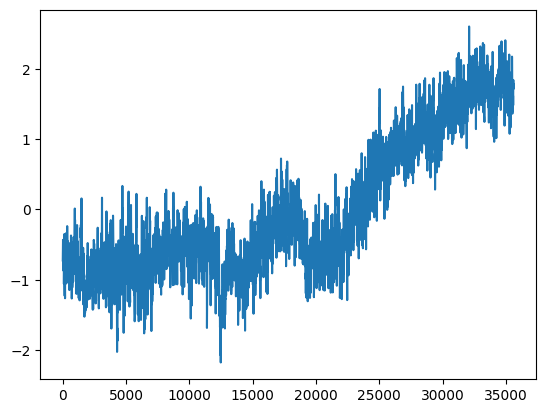

In [56]:
scaled = dropped_out.copy()
for i, row in dropped_out.iterrows():
    row_mean = row.mean()
    row_std = row.std(ddof=0) if row.std(ddof=0) != 0 else 1
    scaled.iloc[i] = (row - row_mean) / row_std
plt.plot(scaled.iloc[0])